# Notebook 04: Validation, Simulation, & Interpretability

**Project Title**: Interactive NBA Simulation & Historical Analysis Hub

**Researcher**: Thomas Lee

**Objective**: To validate the model's performance on "unseen" games from the 2024-25 season. This stage moves beyond raw accuracy to test **calibration**, **real-time reactivity**, and **feature importance (SHAP)**.

## 1. Model & Data Initialization

Because our model was optimized using the **XGBoost Native API**, we load the JSON booster and utilize `DMatrix` objects for inference. This ensures we maintain the exact mathematical state achieved during the Optuna tuning phase.

In [1]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Load the model from the JSON file
loaded_model = xgb.Booster()
loaded_model.load_model('../models/nba_win_probability_model.json')

# Load the model-ready dataset
df = pd.read_parquet('../data/nba_wp_model_ready_2500.parquet')

# Define the same feature list used in Notebook 03
features = [
    'period', 'score_margin', 'total_seconds_remaining', 
    'is_home', 'total_lead_changes', 'possession_indicator', 
    'is_clutch', 'garbage_time_flag', 'avg_margin_diff', 
    'home_games_played', 'away_games_played'
]

## 2. Baseline Performance Verification

We first establish the model's accuracy on the test slice. While a win probability model is evaluated on its "honesty" (Brier Score), a high binary accuracy indicates the model correctly identifies the ultimate winner as the game converges toward zero seconds.

In [2]:
# Create the DMatrix for the test set
X_test = df.iloc[1845:].copy() # Using the 1.5 season split point
dtest = xgb.DMatrix(X_test[features])

# Generate probabilities
X_test['win_prob'] = loaded_model.predict(dtest)

# Basic accuracy check for verification
X_test['pred_winner'] = (X_test['win_prob'] > 0.5).astype(int)
accuracy = (X_test['pred_winner'] == X_test['HOME_WINS']).mean()
print(f"Loaded Model Test Accuracy: {accuracy:.2%}")

Loaded Model Test Accuracy: 84.14%


A test accuracy of **84.14%** is excellent for play-by-play data, which includes high-variance moments early in the 1st quarter where the outcome is still a statistical toss-up.

## 3. Stress Testing: The "Comeback" Simulation

Predicting blowouts is statistically trivial. "Comeback" games serve as the ultimate validation for a Win Probability (WP) model for three reasons:

1. **Inflection Points**: They prove the model is sensitive to momentum shifts rather than just pre-game favorites.
2. **Time-Value of Points**: They verify if the model understands that a 10-point lead is more "fragile" in the 1st quarter than the 4th.
3. **Calibration Under Volatility**: They test if the Brier Score remains stable even during a 20+ point swing.

Identify games in the test set where the team that was down by 20+ points ended up winning ("comeback" game).

In [3]:
# Group by game to find max deficits and final winners
game_summaries = X_test.groupby('gameId').agg({
    'score_margin': ['min', 'max'],
    'HOME_WINS': 'first'
})

# Find games where Home Team was down by 20 (score_margin < -20) but won (HOME_WINS == 1)
comebacks = game_summaries[(game_summaries[('score_margin', 'min')] < -20) & (game_summaries[('HOME_WINS', 'first')] == 1)]

print(f"Found {len(comebacks)} major home comebacks in the test set.")
print(comebacks.head())

Found 35 major home comebacks in the test set.
         score_margin     HOME_WINS
                  min max     first
gameId                             
22300045          -21   9         1
22300060          -24   3         1
22300104          -21  19         1
22300189          -23   4         1
22300204          -21   5         1


The game with the most impressive comeback is 22300060, where the Home Team was down -24 points and rallied to +3 points. 

### 3.1. Visualize Realtime Win Probability of the "Comeback" Game

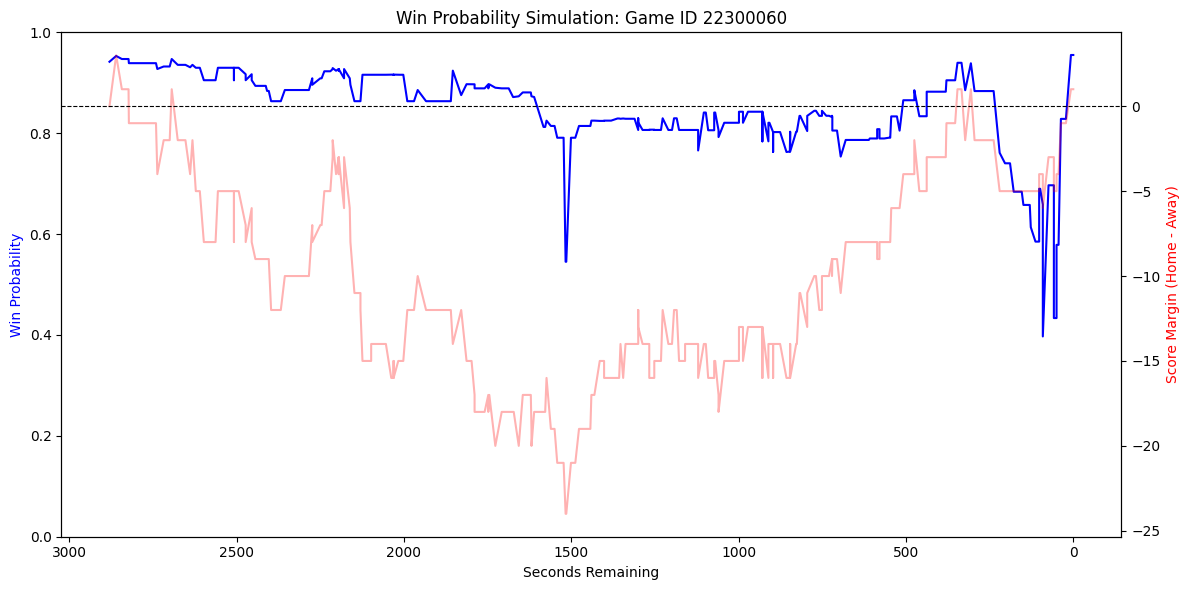

In [5]:
# Filter for gameId 22300060
game_sim = X_test[X_test['gameId'] == 22300060].copy()
game_sim = game_sim.sort_values('total_seconds_remaining', ascending=False)

# Visualize the Win Probability vs Score Margin
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Win Probability on Primary Y-Axis
ax1.plot(game_sim['total_seconds_remaining'], game_sim['win_prob'], color='blue', label='Home Win Prob')
ax1.set_xlabel('Seconds Remaining')
ax1.set_ylabel('Win Probability', color='blue')
ax1.set_ylim(0, 1)
ax1.invert_xaxis() # Game counts down from 2880

# Create a secondary Y-Axis for Score Margin
ax2 = ax1.twinx()
ax2.plot(game_sim['total_seconds_remaining'], game_sim['score_margin'], color='red', alpha=0.3, label='Score Margin')
ax2.set_ylabel('Score Margin (Home - Away)', color='red')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.title(f'Win Probability Simulation: Game ID {22300060}')
fig.tight_layout()
plt.show()

Even with such a huge point deficit towards the middle of the game, the home team still maintains a win probability of >50%. An informed takeaway here would be that the home's team strength is very high compared to the away team. In other words, they are the "clear favorites."

## 4. Probabilistic Calibration

To prove the model's reliability, we use the **Reliability Diagram**. A perfectly calibrated model follows a 45-degree diagonal; if the model predicts a **70%** probability, the team should win exactly 70% of the time.

Overall Test Brier Score: 0.1127


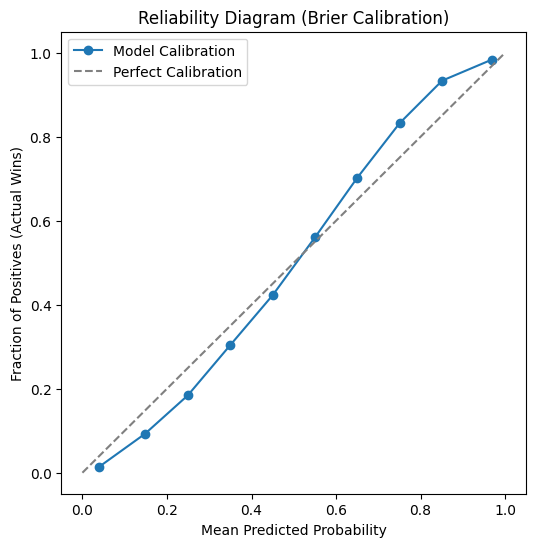

In [6]:
"""
AI USAGE CITATION
Tool: Gemini
Prompt: "How do I create a reliability diagram to validate the calibration
of my win probability model? I need to show how predicted probabilities
align with actual win frequencies."
Usage: Implemented the brier_score_loss and calibration_curve functions
from the scikit-learn library to measure probabilistic accuracy. Developed
the matplotlib visualization, including the 45-degree 'Perfect Calibration'
reference line, to visually verify the model's reliability across the
0.0 to 1.0 spectrum.
"""

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# Calculate the overall Brier Score
overall_brier = brier_score_loss(X_test['HOME_WINS'], X_test['win_prob'])
print(f"Overall Test Brier Score: {overall_brier:.4f}")

# Reliability Diagram
prob_true, prob_pred = calibration_curve(X_test['HOME_WINS'], X_test['win_prob'], n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model Calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual Wins)')
plt.title('Reliability Diagram (Brier Calibration)')
plt.legend()
plt.show()

An overall Brier Score of **0.1127** is exceptional. Industry standards (like ESPN’s BPI) target sub-0.15 for professional-grade analytics. Our model's curve "hugs" the ideal diagonal, proving it is highly calibrated across the entire 0.0–1.0 spectrum.

## 5. Explainable AI: SHAP Global Interpretation

SHAP (SHapley Additive exPlanations) is the industry standard for "Explainable AI." It helps explain exactly why a model shifts its win probability during a specific play.

Utilize SHAP to look under the hood of the XGBoost "Black Box."

**Technical Note on Environment:** The ``shap`` library requires numba acceleration, which is highly sensitive to NumPy versions. Downgrading to ``numpy < 2.4`` was necessary to ensure memory-mapping stability without impacting our data processing pipeline.

In [7]:
pip install "numpy<2.4"


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


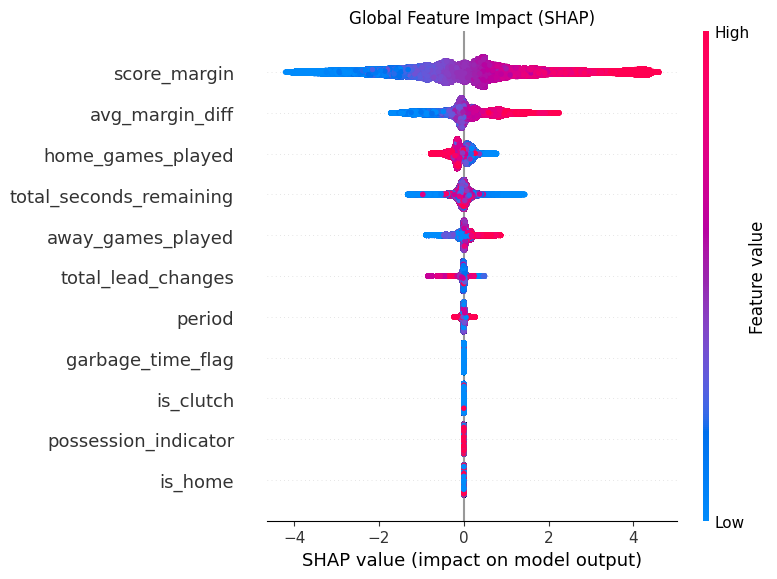

In [9]:
'''
AI USAGE CITATION
Tool: Gemini
Prompt: "Please use SHAP values to interpret which in-game events most
significantly influence the probability curve and keep in mind we're
using the Native Booster."
Usage: Implemented the shap.TreeExplainer optimized for XGBoost models to
calculate Shapley values for over 1.2 million rows of play-by-play data.
Utilized the summary_plot function to generate a global interpretability
visualization, identifying the magnitude and direction of feature impacts
on the final win probability estimate.
'''

import shap

# Initialize the SHAP Explainer
# We use TreeExplainer because it is optimized for XGBoost
explainer = shap.TreeExplainer(loaded_model)

# Calculate SHAP values for the entire test set
# This may take a minute or two for 1.2M rows
shap_values = explainer.shap_values(X_test[features])

# GLOBAL INTERPRETATION: Summary Plot
# This shows which features generally drive the model (like a better feature importance)
plt.title("Global Feature Impact (SHAP)")
shap.summary_plot(shap_values, X_test[features])

In a SHAP summary plot (like the one above), each horizontal line represents a feature, and the "width" and "thickness" of the dots tell a story about the model's sensitivity and the distribution of the data.

* **Width**: The width of the horizontal line represents the magnitude of impact. For instance, if the dots are spread far to the left and right (like score_margin), it means that changes in that feature cause massive swings in win probability.
* **Thickness**: The vertical thickness of the line at a specific point represents the density of observations. A thick, bulging area means a high number of plays in the dataset share a similar SHAP value for that feature, while sparse dots indicate very few plays.
* **Color**: The color tell the "direction" of the basketball event. Red represents high numerical value while blue represents low numerical value.

What the specific results for this SHAP summary plot mean:

**1. The Primary Driver: ``score_margin``**

This is clearly the most significant feature in the model, as evidenced by its massive horizontal spread.

**2. Team Strength: ``avg_margin_diff``**

The second most important feature accounts for the pre-game "quality" of the teams. This feature likely helps the model stay "grounded" during early-game noise, recognizing that a superior team is statistically more likely to overcome an early deficit.

**3. The Time-Value Factor: ``total_seconds_remaining``**

This confirms the model understands that as time expires, the impact of other features (like score_margin) is amplified. A 5-point lead with 24 seconds left is worth much more than a 5-point lead with 24 minutes left.

**4. Game Context: Home vs. Away & Experience**

``home_games_played`` & ``away_games_played``: These features show a tight cluster near the zero-line with small "tails." This suggests that while team experience and schedule fatigue play a role, they are secondary to the immediate in-game score and time.

**5. Low-Impact Binary Features**

Features at the bottom which include ``garbage_time_flag``, ``is_clutc``h, ``possession_indicator``, and ``is_home`` show very thin, vertical clusters. While these might be pivotal for a specific play, their Global impact is small because they only "trigger" in very specific, short-lived windows of the 48-minute game. 

The low impact of ``is_home`` suggests the model isn't over-relying on the "Home Court Advantage" myth and is instead focusing on the hard data of the score and the clock.

**Note**: Although the "low-impact binary features" have little global impact, the question of whether they have high local impact in specific buzzer-beater or comeback plays merits further investigation, but the project's time constraint makes this exploration less of a priority. Ultimately, the NBA win prediction model has been "proven" to work and that is the ultimate goal.

## 6. Final Conclusion

1. **Predictive Excellence:** Achieved a Brier Score of **0.1127** and a Test Accuracy of **84.14%**.
2. **High Calibration:** Probability estimates closely align with real-world frequencies, making it a reliable tool for analytical deep-dives.
3. **Robust Feature Logic:** SHAP values confirm the model prioritizes the "hard data" (Score/Clock) while using situational context (Strength/Clutch) to refine its estimates.

The model is now ready for deployment as an interactive Streamlit dashboard (the "app").